In [1]:
import os
import json
import random
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import tensorflow as tf

from sklearn.model_selection import train_test_split

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [2]:
zip_path = "/content/RMDS_segmentation_dataset_ADE20K_350.zip"
extract_path = "/content/ADE20K"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [3]:
TRAIN_PATH = "/content/ADE20K/train"
VAL_PATH = "/content/ADE20K/val"
TEST_PATH = "/content/ADE20K/test"

print(TRAIN_PATH)
print(VAL_PATH)
print(TEST_PATH)

/content/ADE20K/train
/content/ADE20K/val
/content/ADE20K/test


In [4]:
for root, dirs, files in os.walk(extract_path):
    print(root, len(files))

/content/ADE20K 2
/content/ADE20K/val 350
/content/ADE20K/train 350
/content/ADE20K/__MACOSX 5
/content/ADE20K/__MACOSX/val 350
/content/ADE20K/__MACOSX/train 350
/content/ADE20K/__MACOSX/test 30
/content/ADE20K/test 30


In [5]:
for root, dirs, files in os.walk("/content/ADE20K"):
    print(root)

/content/ADE20K
/content/ADE20K/val
/content/ADE20K/train
/content/ADE20K/__MACOSX
/content/ADE20K/__MACOSX/val
/content/ADE20K/__MACOSX/train
/content/ADE20K/__MACOSX/test
/content/ADE20K/test


In [6]:
def count_images(folder):
    count = 0
    for file in os.listdir(folder):
        if file.endswith((".jpg",".png",".jpeg")):
            count += 1
    return count

print("Training Images :", count_images(TRAIN_PATH))
print("Validation Images :", count_images(VAL_PATH))
print("Test Images :", count_images(TEST_PATH))

Training Images : 350
Validation Images : 350
Test Images : 30


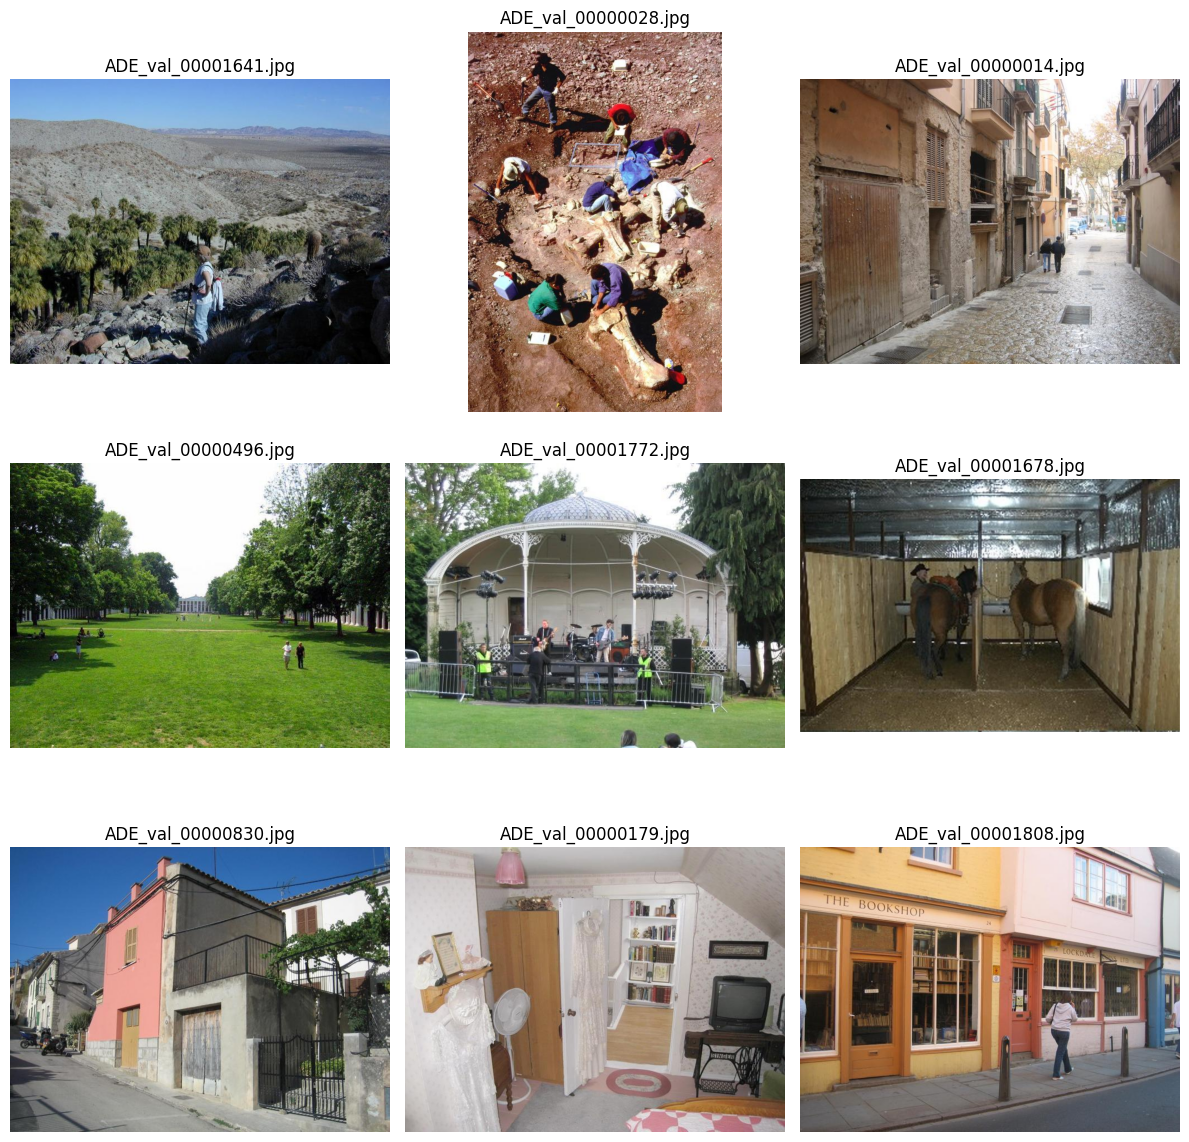

In [7]:
image_files = [
    f for f in os.listdir(TRAIN_PATH)
    if f.endswith((".jpg",".png",".jpeg"))
]

random_images = random.sample(image_files, 9)

plt.figure(figsize=(12,12))

for i, img_name in enumerate(random_images):

    img = Image.open(os.path.join(TRAIN_PATH,img_name))

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(img_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
train_annotation_file = f"{extract_path}/instances_train.json"

In [9]:
from pycocotools.coco import COCO  # API for COCO dataset.

coco = COCO(train_annotation_file)


loading annotations into memory...
Done (t=0.03s)
creating index...
index created!


In [10]:
# Print all category names

cats = coco.loadCats(coco.getCatIds())

print("Total Categories:", len(cats))

for cat in cats:
    print(cat['id'], cat['name'])

Total Categories: 100
1 bed
2 windowpane
3 cabinet
4 person
5 door
6 table
7 curtain
8 chair
9 car
10 painting
11 sofa
12 shelf
13 mirror
14 armchair
15 seat
16 fence
17 desk
18 wardrobe
19 lamp
20 bathtub
21 railing
22 cushion
23 box
24 column
25 signboard
26 chest of drawers
27 counter
28 sink
29 fireplace
30 refrigerator
31 stairs
32 case
33 pool table
34 pillow
35 screen door
36 bookcase
37 coffee table
38 toilet
39 flower
40 book
41 bench
42 countertop
43 stove
44 palm
45 kitchen island
46 computer
47 swivel chair
48 boat
49 arcade machine
50 bus
51 towel
52 light
53 truck
54 chandelier
55 awning
56 streetlight
57 booth
58 television receiver
59 airplane
60 apparel
61 pole
62 bannister
63 ottoman
64 bottle
65 van
66 ship
67 fountain
68 washer
69 plaything
70 stool
71 barrel
72 basket
73 bag
74 minibike
75 oven
76 ball
77 food
78 step
79 trade name
80 microwave
81 pot
82 animal
83 bicycle
84 dishwasher
85 screen
86 sculpture
87 hood
88 sconce
89 vase
90 traffic light
91 tray
92 ash

In [11]:
target_classes = ['person', 'car', 'book', 'airplane']

#cat_ids = coco.getCatIds(catNms=target_classes)

#print(cat_ids)

In [12]:
cat_ids = coco.getCatIds(catNms=target_classes)

print("Category IDs:", cat_ids)

image_ids = set()

for cat_id in cat_ids:
    ann_ids = coco.getAnnIds(catIds=[cat_id])
    anns = coco.loadAnns(ann_ids)

    for ann in anns:
        image_ids.add(ann['image_id'])

image_ids = list(image_ids)

print("Total images:", len(image_ids))

Category IDs: [4, 9, 40, 59]
Total images: 350


In [13]:
# Background = 0
# Person = 1
# Car = 2
# Book = 3
# Airplane = 4

CLASS_MAP = {
    4: 1,    # person
    9: 2,    # car
    40: 3,   # book
    59: 4    # airplane
}

NUM_CLASSES = 5

In [14]:
target_ids = list(CLASS_MAP.keys())

#image_ids = coco.getImgIds(catIds=target_ids)

print("Number of images containing target classes:", len(image_ids))
print("First 10 image IDs:", image_ids[:10])

Number of images containing target classes: 350
First 10 image IDs: [20500, 20502, 20513, 20515, 20540, 20554, 20556, 20575, 20579, 20585]


In [15]:
# Print all category IDs and names

category_IDs = coco.getCatIds()
categories = coco.loadCats(category_IDs)

print(f"Total categories: {len(categories)}\n")

for cat in categories:
    print(f"ID: {cat['id']:3d} | Name: {cat['name']}")

Total categories: 100

ID:   1 | Name: bed
ID:   2 | Name: windowpane
ID:   3 | Name: cabinet
ID:   4 | Name: person
ID:   5 | Name: door
ID:   6 | Name: table
ID:   7 | Name: curtain
ID:   8 | Name: chair
ID:   9 | Name: car
ID:  10 | Name: painting
ID:  11 | Name: sofa
ID:  12 | Name: shelf
ID:  13 | Name: mirror
ID:  14 | Name: armchair
ID:  15 | Name: seat
ID:  16 | Name: fence
ID:  17 | Name: desk
ID:  18 | Name: wardrobe
ID:  19 | Name: lamp
ID:  20 | Name: bathtub
ID:  21 | Name: railing
ID:  22 | Name: cushion
ID:  23 | Name: box
ID:  24 | Name: column
ID:  25 | Name: signboard
ID:  26 | Name: chest of drawers
ID:  27 | Name: counter
ID:  28 | Name: sink
ID:  29 | Name: fireplace
ID:  30 | Name: refrigerator
ID:  31 | Name: stairs
ID:  32 | Name: case
ID:  33 | Name: pool table
ID:  34 | Name: pillow
ID:  35 | Name: screen door
ID:  36 | Name: bookcase
ID:  37 | Name: coffee table
ID:  38 | Name: toilet
ID:  39 | Name: flower
ID:  40 | Name: book
ID:  41 | Name: bench
ID:  42 |

In [16]:
names = [cat["name"] for cat in categories]

print(names)

['bed', 'windowpane', 'cabinet', 'person', 'door', 'table', 'curtain', 'chair', 'car', 'painting', 'sofa', 'shelf', 'mirror', 'armchair', 'seat', 'fence', 'desk', 'wardrobe', 'lamp', 'bathtub', 'railing', 'cushion', 'box', 'column', 'signboard', 'chest of drawers', 'counter', 'sink', 'fireplace', 'refrigerator', 'stairs', 'case', 'pool table', 'pillow', 'screen door', 'bookcase', 'coffee table', 'toilet', 'flower', 'book', 'bench', 'countertop', 'stove', 'palm', 'kitchen island', 'computer', 'swivel chair', 'boat', 'arcade machine', 'bus', 'towel', 'light', 'truck', 'chandelier', 'awning', 'streetlight', 'booth', 'television receiver', 'airplane', 'apparel', 'pole', 'bannister', 'ottoman', 'bottle', 'van', 'ship', 'fountain', 'washer', 'plaything', 'stool', 'barrel', 'basket', 'bag', 'minibike', 'oven', 'ball', 'food', 'step', 'trade name', 'microwave', 'pot', 'animal', 'bicycle', 'dishwasher', 'screen', 'sculpture', 'hood', 'sconce', 'vase', 'traffic light', 'tray', 'ashcan', 'fan', '

In [17]:
# Target category IDs
TARGET_CAT_IDS = [4, 9, 40, 59]

image_ids = []

for img in coco.dataset["images"]:

    anns = coco.loadAnns(coco.getAnnIds(imgIds=img["id"]))

    found = False

    for ann in anns:

        if ann["category_id"] in TARGET_CAT_IDS:
            found = True
            break

    if found:
        image_ids.append(img["id"])

print("Images found:", len(image_ids))
print(image_ids[:10])

Images found: 350
[21806, 20909, 20213, 21857, 21092, 20221, 20887, 21614, 21106, 21216]


In [18]:
import numpy as np

CLASS_MAP = {
    4: 1,      # person
    9: 2,      # car
    40: 3,     # book
    59: 4      # airplane
}

def create_mask(img_id):

    img_info = coco.loadImgs(img_id)[0]

    h = img_info["height"]
    w = img_info["width"]

    mask = np.zeros((h, w), dtype=np.uint8)

    ann_ids = coco.getAnnIds(imgIds=[img_id])
    anns = coco.loadAnns(ann_ids)

    for ann in anns:

        cat = ann["category_id"]

        if cat not in CLASS_MAP:
            continue

        object_mask = coco.annToMask(ann)

        mask[object_mask.astype(bool)] = CLASS_MAP[cat]

    return mask

In [19]:
IMG_SIZE = 256

images = []
masks = []

for img_id in image_ids:

    img_info = coco.loadImgs(img_id)[0]

    img_path = os.path.join(TRAIN_PATH, img_info["file_name"])

    image = Image.open(img_path).convert("RGB")
    image = image.resize((IMG_SIZE, IMG_SIZE))

    image = np.array(image) / 255.0

    mask = create_mask(img_id)

    mask = Image.fromarray(mask)
    mask = mask.resize((IMG_SIZE, IMG_SIZE), Image.NEAREST)
    mask = np.array(mask)

    images.append(image)
    masks.append(mask)

images = np.array(images, dtype=np.float32)
masks = np.array(masks, dtype=np.uint8)

print(images.shape)
print(masks.shape)

(350, 256, 256, 3)
(350, 256, 256)


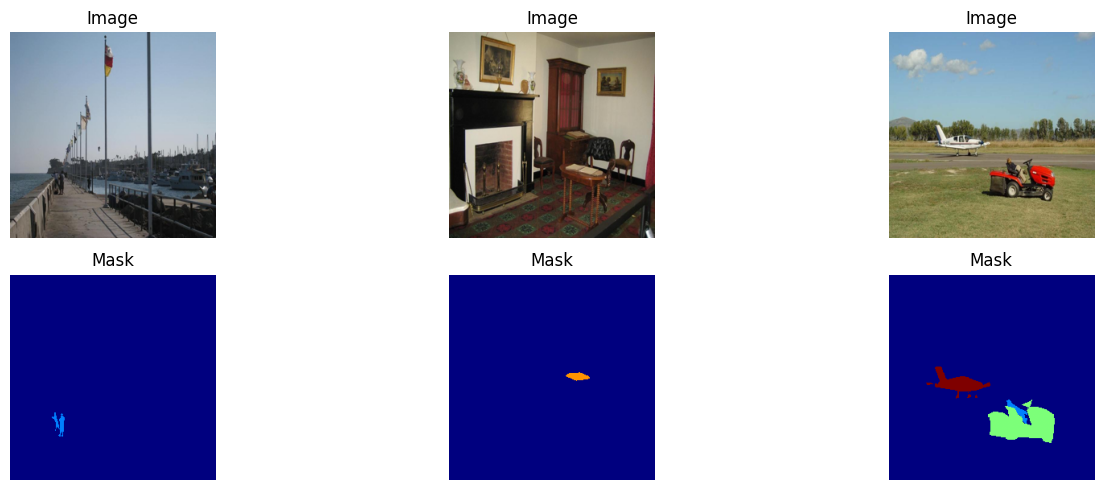

In [20]:
plt.figure(figsize=(15,5))

for i in range(3):

    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    plt.axis("off")
    plt.title("Image")

    plt.subplot(2,3,i+4)
    plt.imshow(masks[i], cmap="jet", vmin=0, vmax=4)
    plt.axis("off")
    plt.title("Mask")

plt.tight_layout()
plt.show()

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    images,
    masks,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_val.shape)

(280, 256, 256, 3)
(70, 256, 256, 3)


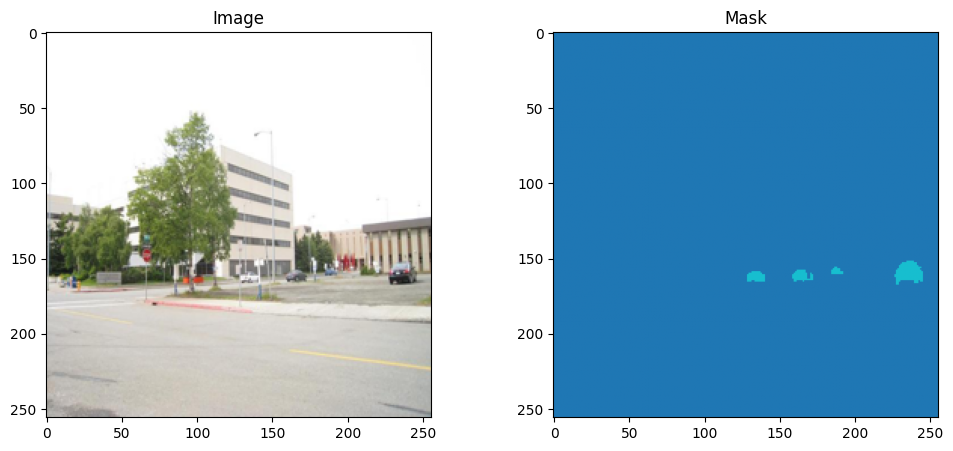

In [22]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(X_train[0])
plt.title("Image")

plt.subplot(1,2,2)
plt.imshow(y_train[0], cmap="tab10")
plt.title("Mask")

plt.show()

In [23]:
img_path = os.path.join(TRAIN_PATH, img_info["file_name"])

In [24]:
img = coco.loadImgs(image_ids[0])[0]
print(img)

{'file_name': 'ADE_val_00001597.jpg', 'width': 683, 'id': 21806, 'height': 512}


In [50]:
from tensorflow.keras import layers, Model

def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, activation='relu', padding='same')(x)
    x = layers.Conv2D(filters, 3, activation='relu', padding='same')(x)
    return x

inputs = layers.Input(shape=(256,256,3))

# Encoder
c1 = conv_block(inputs, 32)
p1 = layers.MaxPooling2D()(c1)

c2 = conv_block(p1, 64)
p2 = layers.MaxPooling2D()(c2)

# Bottleneck
b = conv_block(p2, 128)

# Decoder
u1 = layers.UpSampling2D()(b)
u1 = layers.Concatenate()([u1, c2])
c3 = conv_block(u1, 64)

u2 = layers.UpSampling2D()(c3)
u2 = layers.Concatenate()([u2, c1])
c4 = conv_block(u2, 32)

outputs = layers.Conv2D(5, 1, activation='softmax')(c4)

model = Model(inputs, outputs)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 256, 256,  │        896 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 256, 256,  │      9,248 │ conv2d_11[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 128, 128,  │          0 │ conv2d_12[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 128, 128,  │     18,496 │ max_pooling2d_2[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 128, 128,  │     36,928 │ conv2d_13[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 64, 64,    │          0 │ conv2d_14[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 64, 64,    │     73,856 │ max_pooling2d_3[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 64, 64,    │    147,584 │ conv2d_15[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_2     │ (None, 128, 128,  │          0 │ conv2d_16[0][0]   │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 128, 128,  │          0 │ up_sampling2d_2[… │
│ (Concatenate)       │ 192)              │            │ conv2d_14[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 128, 128,  │    110,656 │ concatenate_2[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 128, 128,  │     36,928 │ conv2d_17[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_3     │ (None, 256, 256,  │          0 │ conv2d_18[0][0]   │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 256, 256,  │          0 │ up_sampling2d_3[… │
│ (Concatenate)       │ 96)               │            │ conv2d_12[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 256, 256,  │     27,680 │ concatenate_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 256, 256,  │      9,248 │ conv2d_19[0][0] 

 Total params: 471,685 (1.80 MB)

 Trainable params: 471,685 (1.80 MB)

 Non-trainable params: 0 (0.00 B)

In [80]:
class_weights = tf.constant([0.2, 1.5, 2.0, 3.0, 4.0], dtype=tf.float32)

def weighted_sparse_categorical_crossentropy(y_true, y_pred):
    y_true = tf.cast(y_true, tf.int32)
    loss = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
    weights = tf.gather(class_weights, y_true)
    loss = loss * weights
    return tf.reduce_mean(loss)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss=weighted_sparse_categorical_crossentropy,
    metrics=['accuracy']
)

In [81]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=8
)

Epoch 1/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 12s 173ms/step - accuracy: 0.8850 - loss: 0.3116 - val_accuracy: 0.7954 - val_loss: 0.3079
Epoch 2/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 115ms/step - accuracy: 0.8631 - loss: 0.2967 - val_accuracy: 0.8159 - val_loss: 0.3006
Epoch 3/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 114ms/step - accuracy: 0.8660 - loss: 0.2860 - val_accuracy: 0.8996 - val_loss: 0.2827
Epoch 4/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 115ms/step - accuracy: 0.8689 - loss: 0.2968 - val_accuracy: 0.9187 - val_loss: 0.2412
Epoch 5/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 116ms/step - accuracy: 0.8623 - loss: 0.2991 - val_accuracy: 0.9300 - val_loss: 0.2775
Epoch 6/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 115ms/step - accuracy: 0.8857 - loss: 0.2917 - val_accuracy: 0.8430 - val_loss: 0.2647
Epoch 7/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 115ms/step - accuracy: 0.8667 - loss: 0.2882 - val_accuracy: 0.8951 - val_loss: 0.2551
Epoch 8/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 117ms/step - accuracy: 0.8690 - loss: 0.2814 - val_accuracy: 0

In [82]:
indices = [20, 23, 52]

predictions = model.predict(X_val[indices])

for i in range(len(indices)):
    pred_mask = np.argmax(predictions[i], axis=-1)
    print(f"Prediction {i}: {np.unique(pred_mask)}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 643ms/step
Prediction 0: [0 1 2 3]
Prediction 1: [0 1 2]
Prediction 2: [0 1 2 3]


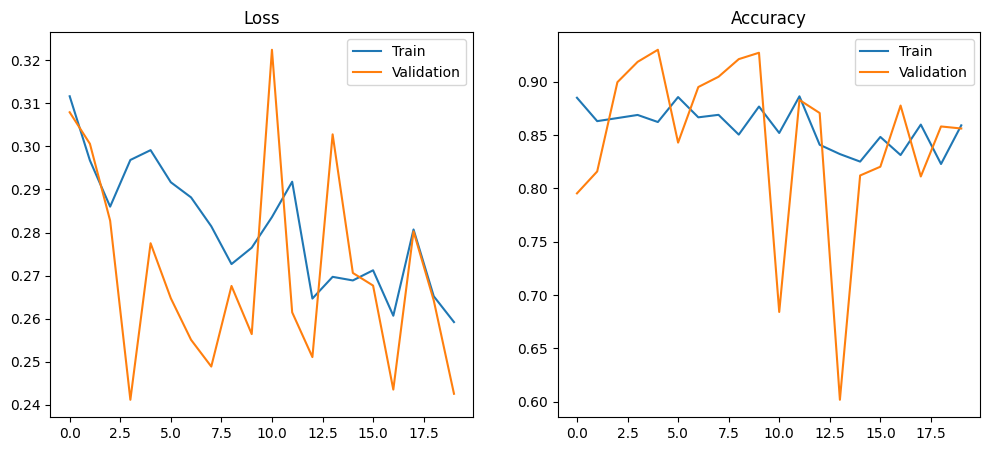

In [83]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title("Accuracy")
plt.legend()

plt.show()

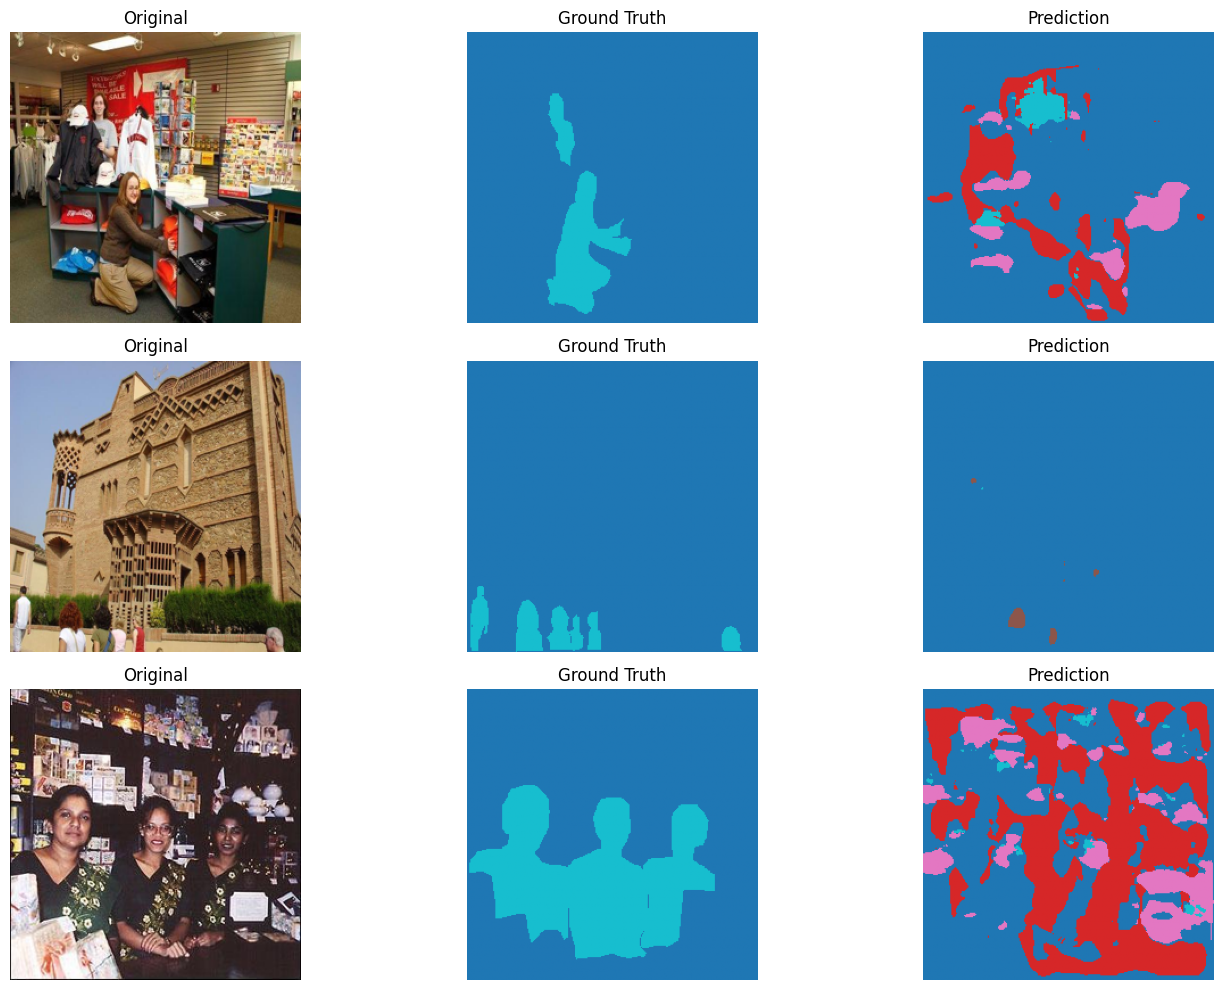

In [84]:
plt.figure(figsize=(15,10))

# Iterate over the indices list to get the actual image index and the plotting index
for plot_idx, val_idx in enumerate(indices):

    plt.subplot(len(indices), 3, plot_idx * 3 + 1)
    plt.imshow(X_val[val_idx]) # Use val_idx for X_val
    plt.title("Original")
    plt.axis("off")

    plt.subplot(len(indices), 3, plot_idx * 3 + 2)
    plt.imshow(y_val[val_idx], cmap="tab10") # Use val_idx for y_val
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(len(indices), 3, plot_idx * 3 + 3)
    plt.imshow(np.argmax(predictions[plot_idx], axis=-1), cmap="tab10") # Use plot_idx for predictions
    plt.title("Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


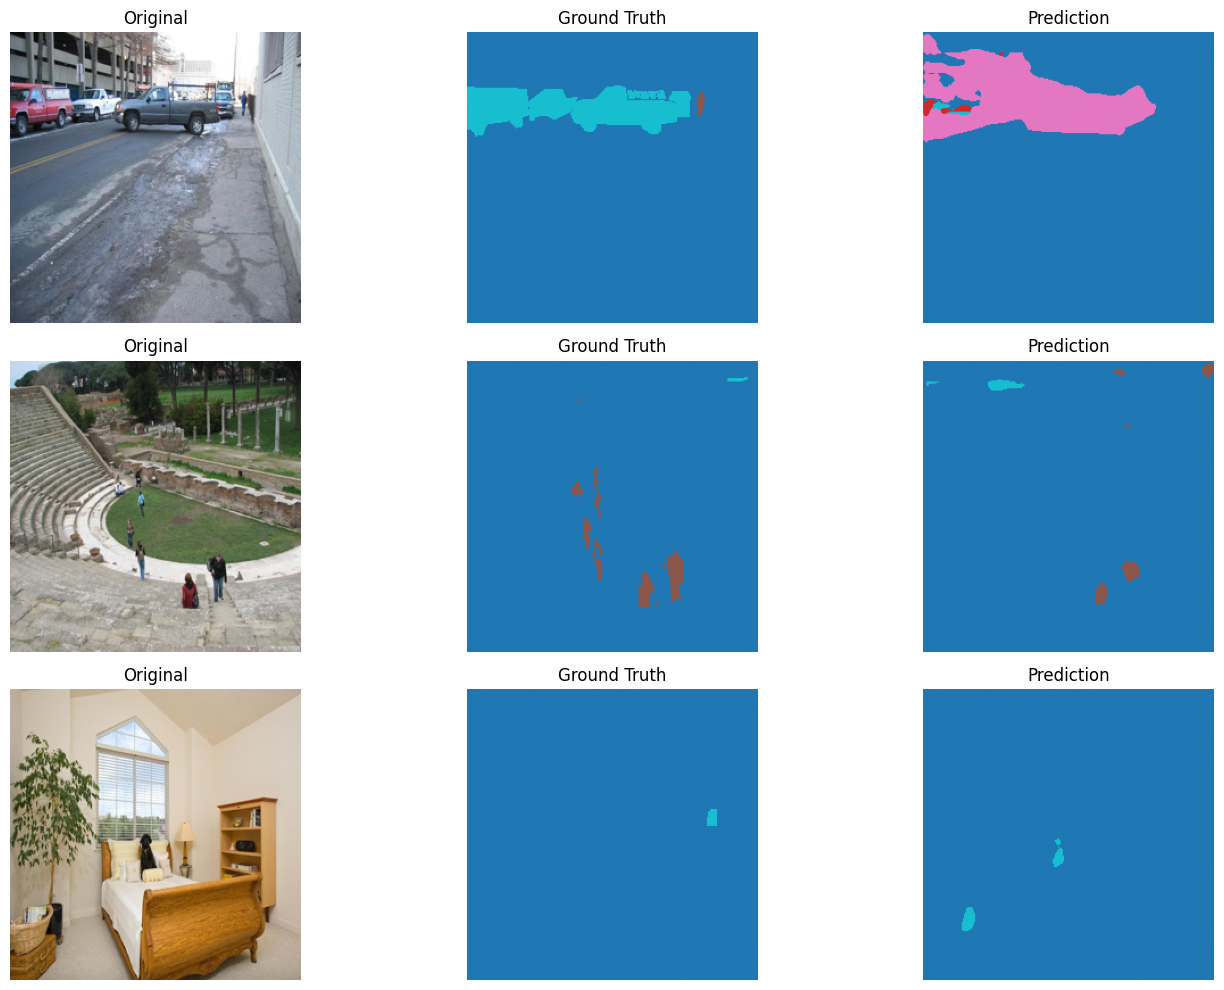

In [85]:
predictions = model.predict(X_val[:3])

plt.figure(figsize=(15,10))

for i in range(3):

    plt.subplot(3,3,i*3+1)
    plt.imshow(X_val[i])
    plt.title("Original")
    plt.axis("off")

    plt.subplot(3,3,i*3+2)
    plt.imshow(y_val[i], cmap="tab10")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(3,3,i*3+3)
    plt.imshow(np.argmax(predictions[i], axis=-1), cmap="tab10")
    plt.title("Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [86]:
predictions_all = model.predict(X_val)

def mean_iou_single(y_true, y_pred, num_classes=5):
    ious = []
    for cls in range(1, num_classes):
        true_cls = (y_true == cls)
        pred_cls = (y_pred == cls)

        intersection = np.logical_and(true_cls, pred_cls).sum()
        union = np.logical_or(true_cls, pred_cls).sum()

        if union > 0:
            ious.append(intersection / union)

    if len(ious) == 0:
        return 0

    return np.mean(ious)

scores = []

for i in range(len(X_val)):
    pred_mask = np.argmax(predictions_all[i], axis=-1)
    score = mean_iou_single(y_val[i], pred_mask)
    scores.append(score)

best_indices = np.argsort(scores)[-3:][::-1]

print("Best 3 image indices:", best_indices)
print("IoU scores:", [scores[i] for i in best_indices])

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 294ms/step
Best 3 image indices: [ 4  7 58]
IoU scores: [np.float64(0.4179786693753174), np.float64(0.38527650131573776), np.float64(0.3368988227670239)]


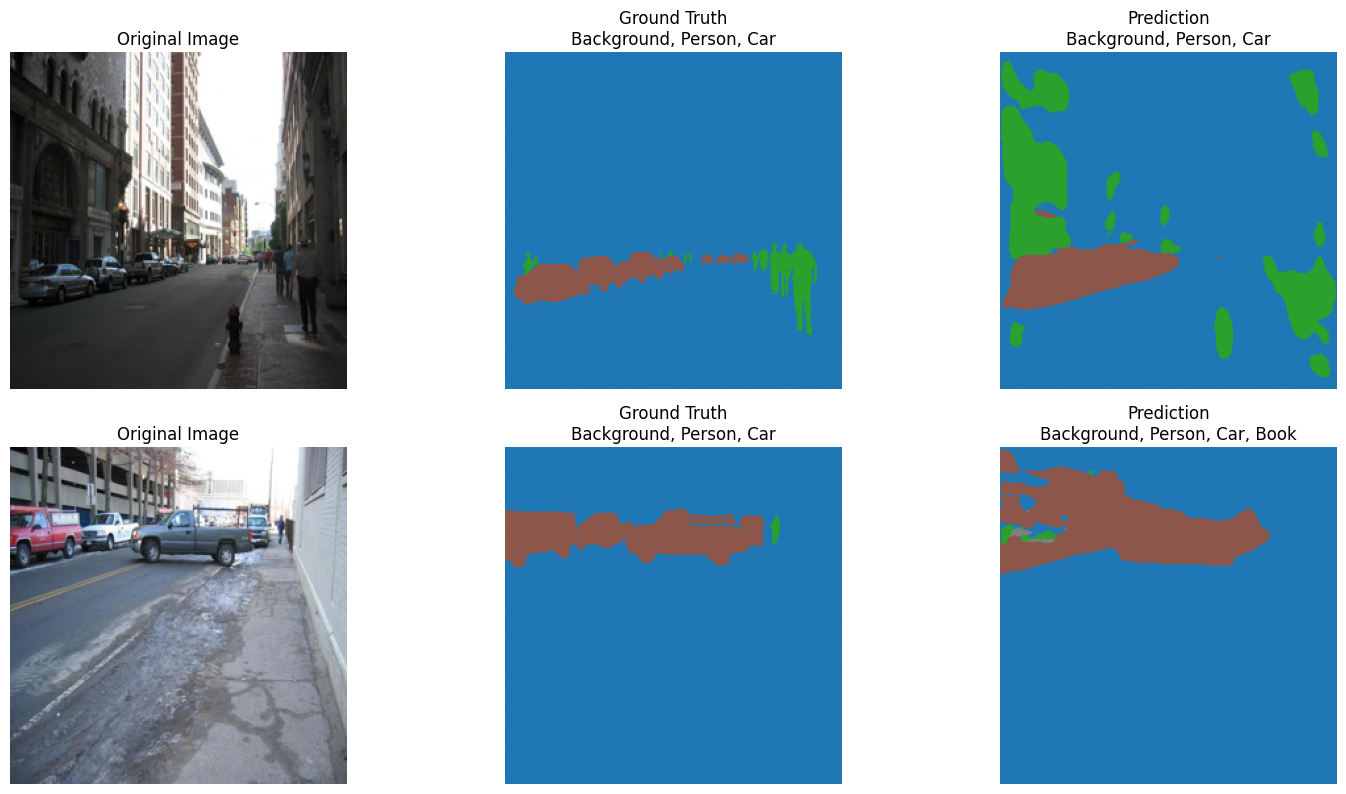

In [87]:
best_indices = [58,0]
class_names = {
    0: "Background",
    1: "Person",
    2: "Car",
    3: "Book",
    4: "Airplane"
}

plt.figure(figsize=(15, 12))

for i, idx in enumerate(best_indices):

    pred_mask = np.argmax(predictions_all[idx], axis=-1)

    gt_labels = [class_names[int(c)] for c in np.unique(y_val[idx])]
    pred_labels = [class_names[int(c)] for c in np.unique(pred_mask)]

    plt.subplot(3, 3, i*3 + 1)
    plt.imshow(X_val[idx])
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(3, 3, i*3 + 2)
    plt.imshow(y_val[idx], cmap="tab10", vmin=0, vmax=4)
    plt.title("Ground Truth\n" + ", ".join(gt_labels))
    plt.axis("off")

    plt.subplot(3, 3, i*3 + 3)
    plt.imshow(pred_mask, cmap="tab10", vmin=0, vmax=4)
    plt.title("Prediction\n" + ", ".join(pred_labels))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [88]:
for target_class in [1, 2, 3, 4]:
    for i in range(len(y_val)):
        if target_class in np.unique(y_val[i]):
            print(f"Class {target_class} found in validation image index: {i}")
            break

Class 1 found in validation image index: 0
Class 2 found in validation image index: 0
Class 3 found in validation image index: 2
Class 4 found in validation image index: 42


Selected images: [0, 0, 2, 42]


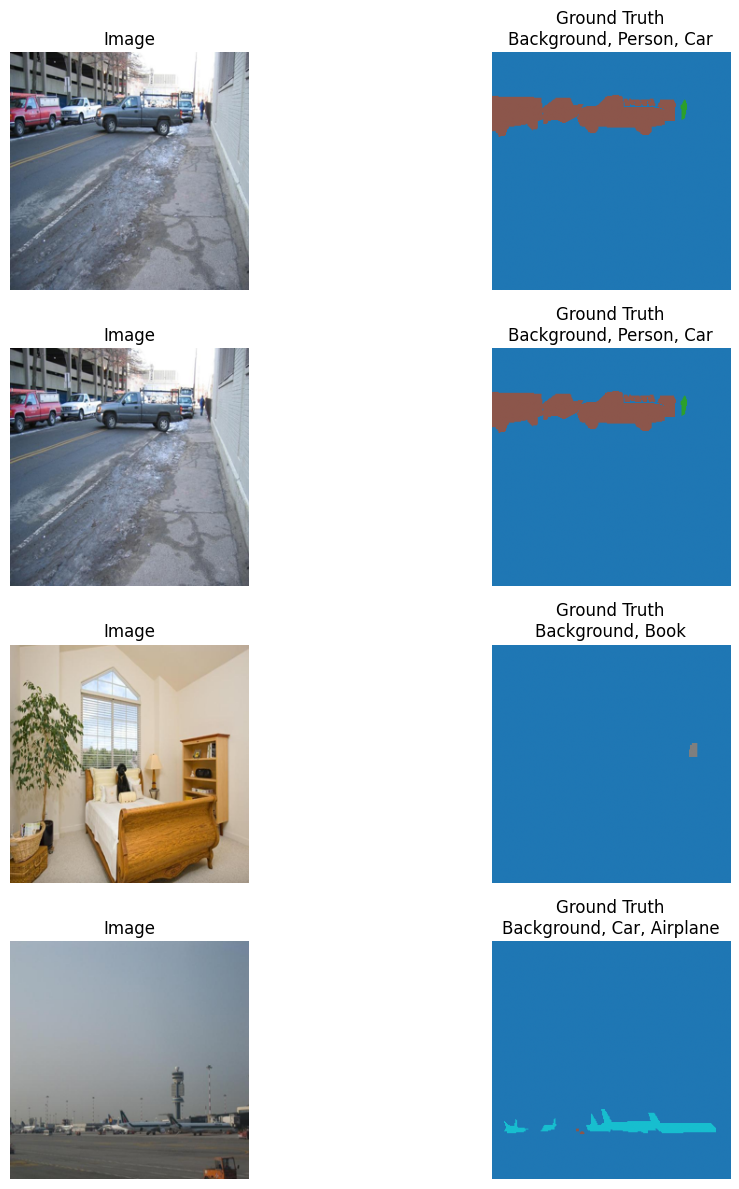

In [89]:
selected_indices = []

for target_class in [1, 2, 3, 4]:
    for i in range(len(y_val)):
        if target_class in np.unique(y_val[i]):
            selected_indices.append(i)
            break

print("Selected images:", selected_indices)

plt.figure(figsize=(12, 12))

for i, idx in enumerate(selected_indices):
    labels = [class_names[int(c)] for c in np.unique(y_val[idx])]

    plt.subplot(len(selected_indices), 2, i*2 + 1)
    plt.imshow(X_val[idx])
    plt.title("Image")
    plt.axis("off")

    plt.subplot(len(selected_indices), 2, i*2 + 2)
    plt.imshow(y_val[idx], cmap="tab10", vmin=0, vmax=4)
    plt.title("Ground Truth\n" + ", ".join(labels))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [90]:
predictions = model.predict(X_val)

predicted_classes = set()

for i in range(len(predictions)):
    pred_mask = np.argmax(predictions[i], axis=-1)
    predicted_classes.update(np.unique(pred_mask))

print("Predicted classes:", sorted(predicted_classes))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
Predicted classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


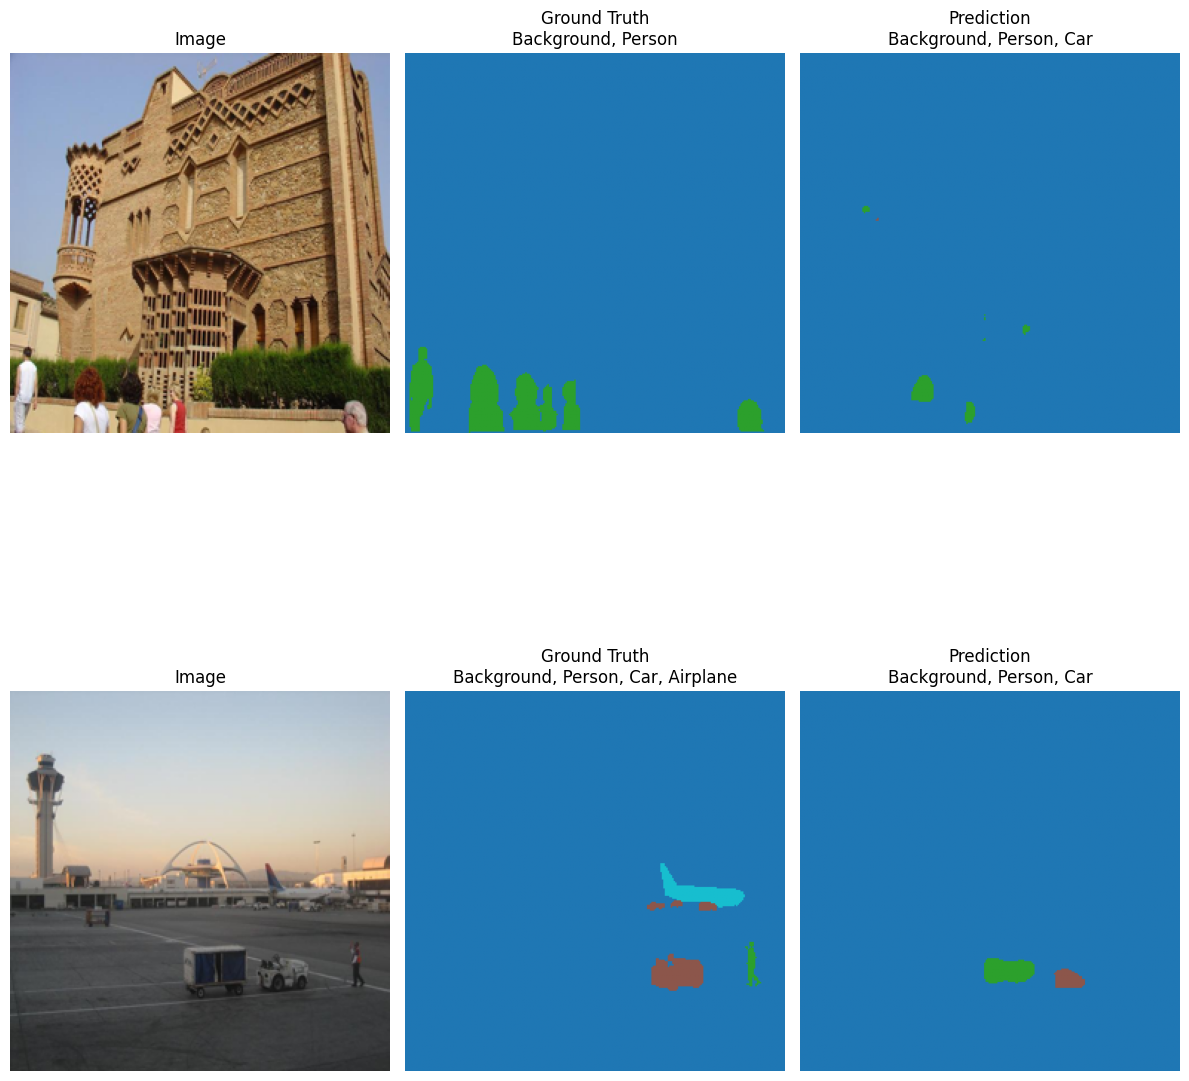

In [94]:
class_names = {
    0: "Background",
    1: "Person",
    2: "Car",
    3: "Book",
    4: "Airplane"
}

indices = [23, 60]

predictions = model.predict(X_val[indices])

plt.figure(figsize=(12, 15))

for i, idx in enumerate(indices):

    pred_mask = np.argmax(predictions[i], axis=-1)

    gt_labels = [class_names[int(c)] for c in np.unique(y_val[idx])]
    pred_labels = [class_names[int(c)] for c in np.unique(pred_mask)]

    # Original image
    plt.subplot(len(indices), 3, i*3 + 1)
    plt.imshow(X_val[idx])
    plt.title("Image")
    plt.axis("off")

    # Ground truth
    plt.subplot(len(indices), 3, i*3 + 2)
    plt.imshow(y_val[idx], cmap="tab10", vmin=0, vmax=4)
    plt.title("Ground Truth\n" + ", ".join(gt_labels))
    plt.axis("off")

    # Prediction
    plt.subplot(len(indices), 3, i*3 + 3)
    plt.imshow(pred_mask, cmap="tab10", vmin=0, vmax=4)
    plt.title("Prediction\n" + ", ".join(pred_labels))
    plt.axis("off")

plt.tight_layout()
plt.show()